In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style('darkgrid')
sns.color_palette("hls", 100)

strings_eobs = """│      test/KGE:aggregate      │     -0.7538076043128967      │                                                                                                                      
│         test/KGE:rr          │      -4.675705909729004      │                                                                                                                      
│         test/KGE:tg          │      0.6250342726707458      │                                                                                                                      
│         test/KGE:tn          │      0.2665952444076538      │                                                                                                                      
│         test/KGE:tx          │      0.7688458561897278      │                                                                                                                      
│     test/PSNR:aggregate      │       33.0385856628418       │                                                                                                                      
│         test/PSNR:rr         │      39.76835250854492       │                                                                                                                      
│         test/PSNR:tg         │      31.993675231933594      │                                                                                                                      
│         test/PSNR:tn         │      28.479616165161133      │                                                                                                                      
│         test/PSNR:tx         │      31.912687301635742      │                                                                                                                      
│     test/SSIM:aggregate      │      0.9539666257508178      │                                                                                                                      
│         test/SSIM:rr         │      0.9387117099961914      │                                                                                                                      
│         test/SSIM:tg         │      0.9677982428029186      │                                                                                                                      
│         test/SSIM:tn         │      0.942763527508779       │                                                                                                                      
│         test/SSIM:tx         │      0.9665930226953827      │                                                                                                                      
│   test/lat_PSNR:aggregate    │       33.0150026516124       │                                                                                                                      
│       test/lat_PSNR:rr       │      39.61415811502209       │                                                                                                                      
│       test/lat_PSNR:tg       │      32.069156395177444      │                                                                                                                      
│       test/lat_PSNR:tn       │      28.648502766812793      │                                                                                                                      
│       test/lat_PSNR:tx       │      31.728193329437264      │                                                                                                                      
│ test/lat_mean_bias:aggregate │      0.4209128262555801      │                                                                                                                      
│    test/lat_mean_bias:rr     │    -1.884610850183138e-05    │                                                                                                                      
│    test/lat_mean_bias:tg     │      0.6044139672881651      │                                                                                                                      
│    test/lat_mean_bias:tn     │      1.2068542949727998      │                                                                                                                      
│    test/lat_mean_bias:tx     │     -0.12759811113014285     │                                                                                                                      
│   test/lat_rmse:aggregate    │      1.3270477247632957      │                                                                                                                      
│       test/lat_rmse:rr       │     0.002024156759826104     │                                                                                                                      
│       test/lat_rmse:tg       │      1.4224208397690343      │                                                                                                                      
│       test/lat_rmse:tn       │      2.242998704291457       │                                                                                                                      
│       test/lat_rmse:tx       │      1.640747198232865       │                                                                                                                      
│   test/mean_bias:aggregate   │     0.45752209424972534      │                                                                                                                      
│      test/mean_bias:rr       │   -1.9782277377089486e-05    │                                                                                                                      
│      test/mean_bias:tg       │      0.6441410183906555      │                                                                                                                      
│      test/mean_bias:tn       │      1.2357032299041748      │                                                                                                                      
│      test/mean_bias:tx       │     -0.04973585158586502     │
│    test/pearson:aggregate    │      0.9050549268722534      │
│       test/pearson:rr        │      0.720156729221344       │
│       test/pearson:tg        │      0.9798758625984192      │
│       test/pearson:tn        │      0.9372726082801819      │
│       test/pearson:tx        │      0.9829143285751343      │
│     test/rmse:aggregate      │      1.3331425189971924      │
│         test/rmse:rr         │     0.00199038814753294      │
│         test/rmse:tg         │      1.441664695739746       │
│         test/rmse:tn         │      2.286583662033081       │
│         test/rmse:tx         │      1.6023310422897339      │""".split("\n")

strings_cmip6 = """│           test/KGE:aggregate           │            0.93500155210495            │                                                                                                  
│        test/KGE:air_temperature        │           0.9459575414657593           │                                                                                                  
│         test/KGE:precipitation         │           0.8583123087882996           │                                                                                                  
│      test/KGE:u_component_of_wind      │           0.9595300555229187           │                                                                                                  
│      test/KGE:v_component_of_wind      │           0.9762061238288879           │                                                                                                  
│          test/PSNR:aggregate           │           38.76809310913086            │                                                                                                  
│       test/PSNR:air_temperature        │           40.10262680053711            │                                                                                                  
│        test/PSNR:precipitation         │            38.4775276184082            │                                                                                                  
│     test/PSNR:u_component_of_wind      │           37.42598342895508            │                                                                                                  
│     test/PSNR:v_component_of_wind      │           39.06624984741211            │                                                                                                  
│          test/SSIM:aggregate           │           0.9640383014663588           │                                                                                                  
│       test/SSIM:air_temperature        │           0.9740167468834812           │                                                                                                  
│        test/SSIM:precipitation         │           0.9468503247087685           │                                                                                                  
│     test/SSIM:u_component_of_wind      │           0.9645393894095784           │                                                                                                  
│     test/SSIM:v_component_of_wind      │           0.9707467448636073           │                                                                                                  
│        test/lat_PSNR:aggregate         │           38.919127604253184           │                                                                                                  
│     test/lat_PSNR:air_temperature      │           41.09573489977472            │                                                                                                  
│      test/lat_PSNR:precipitation       │           37.18725053080599            │                                                                                                  
│   test/lat_PSNR:u_component_of_wind    │           37.915045066079294           │                                                                                                  
│   test/lat_PSNR:v_component_of_wind    │           39.478479920352726           │                                                                                                  
│      test/lat_mean_bias:aggregate      │          0.001999723890147852          │                                                                                                  
│   test/lat_mean_bias:air_temperature   │          0.016313580273994273          │                                                                                                  
│    test/lat_mean_bias:precipitation    │         -0.0015773578933805138         │                                                                                                  
│ test/lat_mean_bias:u_component_of_wind │         -0.0034758622522076247         │                                                                                                  
│ test/lat_mean_bias:v_component_of_wind │         -0.003261464567814723          │                                                                                                  
│        test/lat_rmse:aggregate         │           1.1684441398893224           │                                                                                                  
│     test/lat_rmse:air_temperature      │           1.0150798262956628           │                                                                                                  
│      test/lat_rmse:precipitation       │           2.4026279703890023           │                                                                                                  
│   test/lat_rmse:u_component_of_wind    │           0.6744430237925183           │                                                                                                  
│   test/lat_rmse:v_component_of_wind    │           0.5816257390801047           │                                                                                                  
│        test/mean_bias:aggregate        │          0.001216638134792447          │                                                                                                  
│     test/mean_bias:air_temperature     │          0.005390140227973461          │                                                                                                  
│      test/mean_bias:precipitation      │        -0.00019948923727497458         │                                                                                                  
│   test/mean_bias:u_component_of_wind   │         -0.0001612328051123768         │                                                                                                  
│   test/mean_bias:v_component_of_wind   │        -0.00016286571917589754         │                                                                                                  
│         test/pearson:aggregate         │           0.9773315191268921           │                                                                                                  
│      test/pearson:air_temperature      │           0.9992227554321289           │                                                                                                  
│       test/pearson:precipitation       │           0.9273673295974731           │                                                                                                  
│    test/pearson:u_component_of_wind    │           0.9914780855178833           │
│    test/pearson:v_component_of_wind    │           0.9912582039833069           │
│          test/rmse:aggregate           │           1.133211374282837            │
│       test/rmse:air_temperature        │           1.1380971670150757           │
│        test/rmse:precipitation         │           2.0713062286376953           │
│     test/rmse:u_component_of_wind      │           0.7134867906570435           │
│     test/rmse:v_component_of_wind      │           0.6099550724029541           │""".split('\n')

strings_era = """|      test/KGE:10m_u_component_of_wind      │             0.6493094563484192             │                                                                                          
│      test/KGE:10m_v_component_of_wind      │             0.8107872605323792             │                                                                                          
│          test/KGE:2m_temperature           │             0.9527138471603394             │                                                                                          
│             test/KGE:aggregate             │             0.875346302986145              │                                                                                          
│         test/KGE:geopotential_500          │             0.9889923334121704             │                                                                                          
│          test/KGE:temperature_850          │             0.974928617477417              │                                                                                          
│     test/PSNR:10m_u_component_of_wind      │             27.46288299560547              │                                                                                          
│     test/PSNR:10m_v_component_of_wind      │             27.790306091308594             │                                                                                          
│          test/PSNR:2m_temperature          │             33.097991943359375             │                                                                                          
│            test/PSNR:aggregate             │             32.490257263183594             │                                                                                          
│         test/PSNR:geopotential_500         │             39.62324905395508              │                                                                                          
│         test/PSNR:temperature_850          │             34.47684860229492              │                                                                                          
│     test/SSIM:10m_u_component_of_wind      │             0.793118409771579              │                                                                                          
│     test/SSIM:10m_v_component_of_wind      │             0.7815602405365367             │                                                                                          
│          test/SSIM:2m_temperature          │             0.9115439060421751             │                                                                                          
│            test/SSIM:aggregate             │             0.8810418477780191             │                                                                                          
│         test/SSIM:geopotential_500         │             0.9884738340784076             │                                                                                          
│         test/SSIM:temperature_850          │             0.9305128484613971             │                                                                                          
│   test/lat_PSNR:10m_u_component_of_wind    │             28.284527642633517             │                                                                                          
│   test/lat_PSNR:10m_v_component_of_wind    │             28.134106020996008             │                                                                                          
│        test/lat_PSNR:2m_temperature        │             34.12879892671074              │                                                                                          
│          test/lat_PSNR:aggregate           │             33.32437213394955              │                                                                                          
│       test/lat_PSNR:geopotential_500       │             40.559324257644164             │                                                                                          
│       test/lat_PSNR:temperature_850        │             35.515103821763326             │                                                                                          
│ test/lat_mean_bias:10m_u_component_of_wind │            -0.03872576601493794            │                                                                                          
│ test/lat_mean_bias:10m_v_component_of_wind │            0.03062291363487667             │                                                                                          
│     test/lat_mean_bias:2m_temperature      │            0.05563593718646734             │                                                                                          
│        test/lat_mean_bias:aggregate        │             1.4429977541520205             │                                                                                          
│    test/lat_mean_bias:geopotential_500     │             7.1332962621771445             │                                                                                          
│     test/lat_mean_bias:temperature_850     │            0.03415942377655061             │                                                                                          
│   test/lat_rmse:10m_u_component_of_wind    │             2.0545930380403545             │                                                                                          
│   test/lat_rmse:10m_v_component_of_wind    │             1.9950801765042625             │                                                                                          
│        test/lat_rmse:2m_temperature        │             2.1873432538129576             │                                                                                          
│          test/lat_rmse:aggregate           │             25.847683050208552             │                                                                                          
│       test/lat_rmse:geopotential_500       │             121.65862481263888             │                                                                                          
│       test/lat_rmse:temperature_850        │             1.342773970046334              │                                                                                          
│   test/mean_bias:10m_u_component_of_wind   │            0.00629512220621109             │                                                                                          
│   test/mean_bias:10m_v_component_of_wind   │           0.00014383834786713123           │                                                                                          
│       test/mean_bias:2m_temperature        │            0.009615727700293064            │                                                                                          
│          test/mean_bias:aggregate          │            0.11232016980648041             │                                                                                  
│      test/mean_bias:geopotential_500       │             0.5367674231529236             │                                                                                          
│       test/mean_bias:temperature_850       │            0.00877879373729229             │                                                                                          
│    test/pearson:10m_u_component_of_wind    │             0.9143635034561157             │                                                                                          
│    test/pearson:10m_v_component_of_wind    │             0.9008300304412842             │                                                                                          
│        test/pearson:2m_temperature         │             0.9930681586265564             │                                                                                          
│           test/pearson:aggregate           │             0.9605354070663452             │                                                                                          
│       test/pearson:geopotential_500        │             0.9992231726646423             │                                                                                          
│        test/pearson:temperature_850        │             0.9951918721199036             │                                                                                          
│     test/rmse:10m_u_component_of_wind      │             2.2586138248443604             │                                                                                          
│     test/rmse:10m_v_component_of_wind      │             2.0759692192077637             │                                                                                          
│          test/rmse:2m_temperature          │             2.463438034057617              │                                                                                          
│            test/rmse:aggregate             │             28.753957748413086             │                                                                                          
│         test/rmse:geopotential_500         │             135.45591735839844             │                                                                                          
│         test/rmse:temperature_850          │             1.5158307552337646             │""".split("\n")



def get_metrics(metrics_filename):
   
    with open(metrics_filename, 'rb') as f:
        data = pickle.load(f).T

    if 'era' in metrics_filename:
        strings = strings_era
        print("era")
    elif 'eobs' in metrics_filename:
        strings = strings_eobs
        print("eobs")
    else:
        print("cmip6")
        
        strings = strings_cmip6
    final_data = pd.concat([
        data, 
        pd.DataFrame(
            {
                string.split()[1]:[float(string.split()[3])] for string in strings},
                index=['baseline']
        )
    ])

    return final_data

In [2]:
era_cols = [
    'test/lat_rmse:2m_temperature',   'test/lat_rmse:geopotential_500',
    'test/lat_rmse:10m_u_component_of_wind', 'test/lat_rmse:10m_v_component_of_wind',
    
    'test/SSIM:2m_temperature', 'test/SSIM:geopotential_500',
    'test/SSIM:10m_u_component_of_wind', 'test/SSIM:10m_v_component_of_wind', 
    
    'test/lat_PSNR:2m_temperature','test/lat_PSNR:geopotential_500',
    'test/lat_PSNR:10m_u_component_of_wind', 'test/lat_PSNR:10m_v_component_of_wind', 
    
    'test/pearson:2m_temperature', 'test/pearson:geopotential_500',
    'test/pearson:10m_u_component_of_wind', 'test/pearson:10m_v_component_of_wind', 
    
    'test/lat_mean_bias:2m_temperature', 'test/lat_mean_bias:geopotential_500',
    'test/lat_mean_bias:10m_u_component_of_wind', 'test/lat_mean_bias:10m_v_component_of_wind', 
    
]

# print(df_list[0][era_cols].astype('float').round(3).iloc[:, :12].to_latex().replace('000', ''))

In [161]:
metrics_to_select = ['test/lat_rmse:air_temperature', 'test/lat_rmse:precipitation', 'test/lat_rmse:u_component_of_wind', 'test/lat_rmse:v_component_of_wind', 
    'test/SSIM:air_temperature', 'test/SSIM:precipitation', 'test/SSIM:u_component_of_wind', 'test/SSIM:v_component_of_wind',
    'test/lat_PSNR:air_temperature', 'test/lat_PSNR:precipitation', 'test/lat_PSNR:u_component_of_wind', 'test/lat_PSNR:v_component_of_wind'] +\
    ['test/lat_mean_bias:air_temperature', 'test/lat_mean_bias:precipitation', 'test/lat_mean_bias:u_component_of_wind', 
     'test/lat_mean_bias:v_component_of_wind', 
    'test/pearson:air_temperature', 'test/pearson:precipitation', 'test/pearson:u_component_of_wind', 'test/pearson:v_component_of_wind']

model2type = {
    'baseline': 'baseline',
    'esrgan': 'generative',
    'deepsd': 'CNN',
    'edrn': 'CNN',
    'diffusion': 'generative',
    'vit': 'transformer',
    'unet': 'CNN',
    'resnet': 'CNN',
    'ynet': 'CNN',
    'hat': 'transformer'
}

model2name = {'resnet': 'ResNet',
 'unet': 'U-Net',
 'deepsd': 'DeepSD',
 'ynet': 'Y-Net',
 'edrn': 'EDRN',
 'vit': 'ViT',
 'hat': 'HAT',
 'esrgan': 'ESRGAN',
 'diffusion': 'Diffusion',
 'baseline': 'Bilinear'
}

# metrics_to_select += era_cols

# print(final_data[metrics_to_select].astype(float).round(4).to_latex().replace('00', ''))
# filenames = ['metrics_42.pkl', 'metrics_123.pkl', 'metrics_777.pkl']
filenames = [
#    'metrics_42_era.pkl', 'metrics_123_era.pkl', 'metrics_777_era.pkl',
#    'metrics_42.pkl', 'metrics_123.pkl', 'metrics_777.pkl',
    'metrics_42_eobs.pkl', 'metrics_123_eobs.pkl', 'metrics_777_eobs.pkl'
]

def get_ranks(filenames, metrics_to_select):
    df_list = []
    for filename in filenames:
        df_list.append(get_metrics(filename).dropna(axis=1))
    
    for df in df_list:
    #    for metric_name in metrics_to_select:
        for metric_name in df.columns.tolist():
            if 'rmse' in metric_name:
                df[metric_name + '_argsort'] = df[metric_name].rank()
            elif 'SSIM' in metric_name or 'PSNR' in metric_name or 'pearson' in metric_name:
                df[metric_name + '_argsort'] = (-df[metric_name]).rank()
            elif 'mean_bias' in metric_name:
                df[metric_name + '_argsort'] = (df[metric_name].abs()).rank()
    
    metrics_common = ['rmse', 'SSIM', 'lat_PSNR', 'lat_mean_bias', 'pearson']
    df_concat = pd.concat(df_list)[[metric + '_argsort' for metric in metrics_to_select]]#.reset_index().groupby('index').agg(['mean', 'std'])
    metric_common2cols = dict()
    for metric_common in metrics_common:
        metric_common2cols[metric_common] = [col for col in df_concat.columns.tolist() if metric_common in col]
    
    df_list2 = []
    df_list3 = []
    for metric_common in metrics_common:
        cols = metric_common2cols[metric_common]
        df_tmp = pd.DataFrame(df_concat[cols].stack()).reset_index().drop('level_1', axis=1)
        df_list3.append(df_tmp)
        df_tmp = df_tmp.groupby('level_0').agg(['mean', 'std'])
        df_tmp.rename(columns={0: metric_common}, inplace=True)
        df_list2.append(df_tmp)

    return df_list2, df_list3 



def visualize(df_list2):
        
    df_tmp = pd.DataFrame(df_list2[0]).reset_index()
    df_tmp.columns = ['model', 'Mean Rank', 'Std Rank']
    df_tmp['log_mean_rank'] = -np.log(df_tmp['Mean Rank'])
    
    df_tmp = df_tmp.sort_values(by='Mean Rank', ascending=False)
    # df_tmp['color'] = [0, 1, 1, 2, 1, 3, 3, 3, 3, 2]
    df_tmp['color'] = df_tmp['model'].apply(lambda x: model2type[x])

    df_tmp['model'] = df_tmp['model'].apply(lambda x: model2name[x])
    df_tmp.rename(columns={'color': ' '}, inplace=True)
    ax = sns.barplot(
        df_tmp,
        x='Mean Rank',
        y="model",
        hue=' ',
        palette=sns.color_palette("Paired"), #tab10 maybe here
#        legend=True,
    #    hue_order=
        formatter={0: 'green', 1: 'yellow', 2: 'blue', 3: 'red'}
    ) #  palette='Paired',
    
    # ax.legend(h, ['baseline', 'gen', 'transformer','cnn'], title="Interested in politics")
    for i in range(len(df_tmp)):
        plt.errorbar(df_tmp['Mean Rank'].iloc[i], i, xerr=df_tmp['Std Rank'].iloc[i], 
                     fmt='none', c='black', capsize=5)


import matplotlib.pyplot as plt
import numpy as np

# Data


def visualize2(df_tmp, name):#models, mean_rank, error, colors):
    df_tmp = df_tmp[0]
    df_tmp.columns = ['model_name', 'Mean Rank', 'Std Rank']
    # print(df_tmp)
    df_tmp = df_tmp.sort_values(by='Mean Rank', ascending=True)
    df_tmp['model_type'] = df_tmp['model_name'].apply(lambda x: model2type[x])
    df_tmp['model_name'] = df_tmp['model_name'].apply(lambda x: model2name[x])
    
    models = df_tmp.iloc[:, 0].values
    mean_rank = df_tmp['Mean Rank']
    error = df_tmp['Std Rank']
    type_of_models = df_tmp.iloc[:, -1].values
    
#    models = ['baseline', 'esrgan', 'deepsd', 'diffusion', 
#          'vit', 'ynet', 'edrn', 'unet', 'resnet', 'hat']
#    mean_rank = [7.0, 8.0, 6.0, 5.0, 3.5, 4.0, 2.5, 3.0, 1.0, 0.5]
#    error = [0.5, 0.6, 0.4, 0.5, 0.2, 0.3, 0.2, 0.4, 0.1, 0.2]

    # Colors for the bars
#    colors = ['#A6C8E0', '#A6E0A6', '#A6D8E0', '#A0B3D5', 
#              '#C1E0B0', '#B0C1A6', '#C0D1B0', '#D5E6B0', 
#              '#B0D6D5', '#B0B3D0']
    type_model2color = {
        'baseline': 'tab:cyan', #'#A6C8E0',
        'generative': 'tab:blue',#'#A0B3D5',
        'transformer': 'tab:green', #'#A6D8E0',
        'CNN':'#A6E0A6'# 'tab:olive'
    }
    colors = [type_model2color[type_model] for type_model in type_of_models]
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bar chart with error bars
    bars = ax.barh(models, mean_rank, xerr=error, color=colors, capsize=5)
    
    # Add labels and title
    ax.set_xlabel('Mean Rank')
    ax.set_ylabel('Model')
#    ax.set_title('era5 + cmip6')
    
    # Create legend
#    plt.legend()
    legend_labels = ['baseline', 'gen', 'cnn', 'transformer']
    ax.legend(legend_labels, loc='best', frameon=True)
    for bar, model, type_of_model in zip(bars, models, type_of_models):
        ax.barh(model, 0, color=bar.get_facecolor(), label=type_of_model)
    
    # Avoid duplicate labels in the legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='best', frameon=True)
    
    # Show grid
    ax.grid(True)
   
    
    # Show plot
    plt.savefig(f'{name}.png', transparent=True)


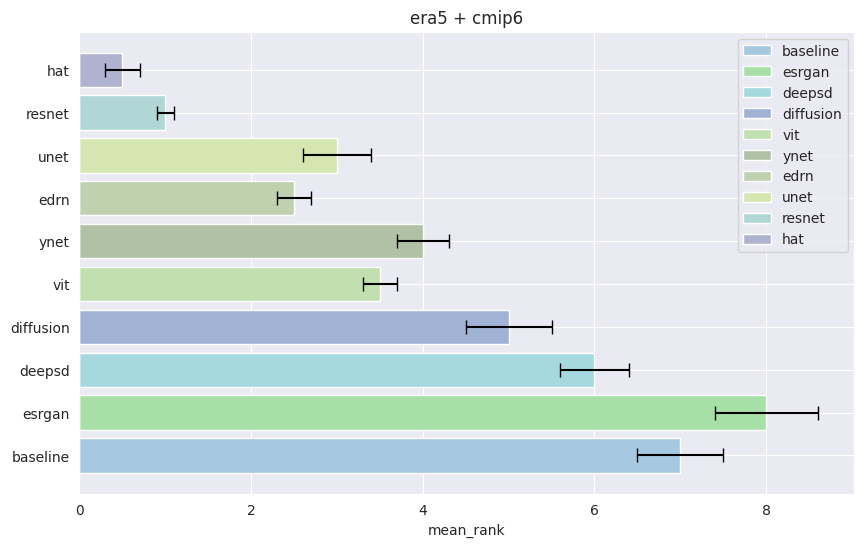

In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['baseline', 'esrgan', 'deepsd', 'diffusion', 
          'vit', 'ynet', 'edrn', 'unet', 'resnet', 'hat']
mean_rank = [7.0, 8.0, 6.0, 5.0, 3.5, 4.0, 2.5, 3.0, 1.0, 0.5]
error = [0.5, 0.6, 0.4, 0.5, 0.2, 0.3, 0.2, 0.4, 0.1, 0.2]

# Colors for the bars
colors = ['#A6C8E0', '#A6E0A6', '#A6D8E0', '#A0B3D5', 
          '#C1E0B0', '#B0C1A6', '#C0D1B0', '#D5E6B0', 
          '#B0D6D5', '#B0B3D0']

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with error bars
bars = ax.barh(models, mean_rank, xerr=error, color=colors, capsize=5)

# Add labels and title
ax.set_xlabel('mean_rank')
ax.set_title('era5 + cmip6')

# Create legend with all models
for bar, model in zip(bars, models):
    ax.barh(model, 0, color=bar.get_facecolor(), label=model)

# Avoid duplicate labels in the legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best', frameon=True)

# Show grid
ax.grid(True)

# Show plot
plt.show()


In [34]:
eobs_cols = [
    'test/lat_PSNR:tg', 'test/lat_PSNR:tx', 'test/lat_PSNR:tn', 'test/lat_PSNR:rr', 
    'test/SSIM:tg', 'test/SSIM:tx', 'test/SSIM:tn', 'test/SSIM:rr',
    'test/lat_rmse:tg', 'test/lat_rmse:tx', 'test/lat_rmse:tn', 'test/lat_rmse:rr',
    'test/lat_mean_bias:tg', 'test/lat_mean_bias:tx', 'test/lat_mean_bias:tn', 'test/lat_mean_bias:rr'
]

In [153]:
ranks_agg_era, ranks_raw_era = get_ranks(['metrics_42_era.pkl', 'metrics_123_era.pkl', 'metrics_777_era.pkl'], era_cols)
ranks_agg_cmip, ranks_raw_cmip = get_ranks(['metrics_42.pkl', 'metrics_123.pkl', 'metrics_777.pkl'], metrics_to_select)
ranks_agg_eobs, ranks_raw_eobs = get_ranks(['metrics_42_eobs.pkl', 'metrics_123_eobs.pkl', 'metrics_777_eobs.pkl'], eobs_cols)

era
era
era
cmip6
cmip6
cmip6
eobs
eobs
eobs


In [97]:
metric_common = 'rmse'

#df_tmp.rename(columns={0: metric_common}, inplace=True)

In [98]:
df_tmp

,model_name,Mean Rank,Std Rank,model_type
2,diffusion,9.750000,0.452267,generative
4,esrgan,9.250000,0.452267,generative
0,baseline,8.000000,0.000000,baseline
1,deepsd,7.000000,0.000000,CNN
9,ynet,5.000000,0.852803,CNN
3,edrn,4.833333,1.114641,CNN
6,resnet,4.083333,1.083625,CNN
8,vit,3.666667,1.614330,transformer
7,unet,2.166667,0.834847,CNN
5,hat,1.250000,0.621582,transformer


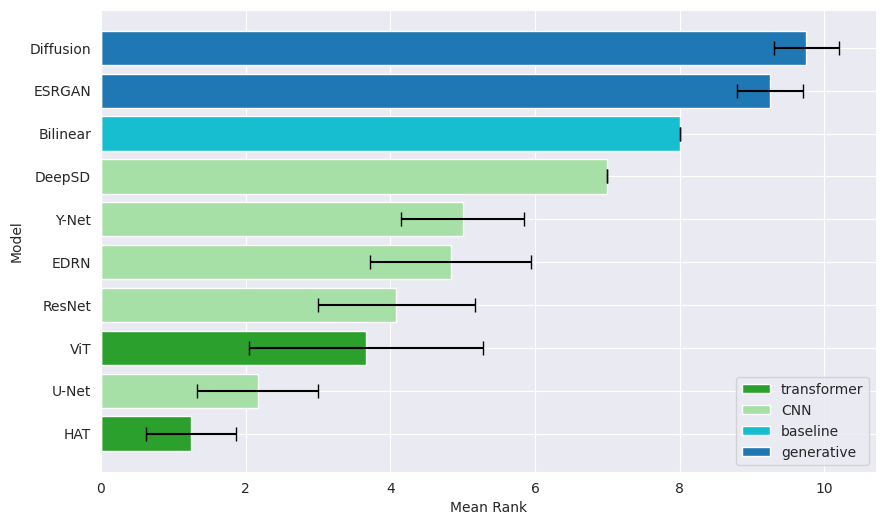

In [164]:
import numpy as np


metric_common = 'rmse'
df_tmp = ranks_agg_eobs[0].reset_index()
df_list2_agg = [df_tmp]
visualize2(df_list2_agg, 'eobs')
plt.savefig("final_image.png", transparent=True)

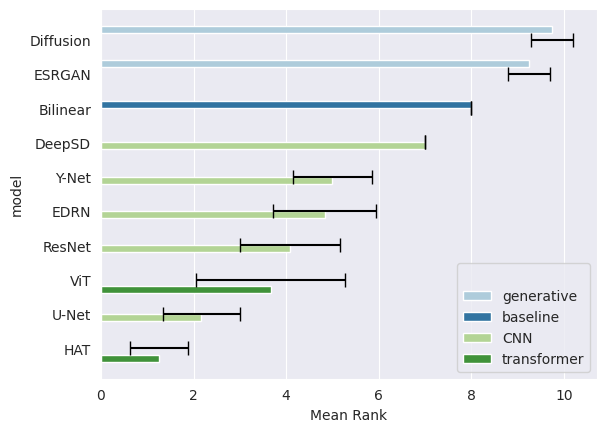

In [29]:
metric_common = 'rmse'
df_tmp = ranks_agg_eobs[0]
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize(df_list2_agg)
plt.savefig("final_image.png")

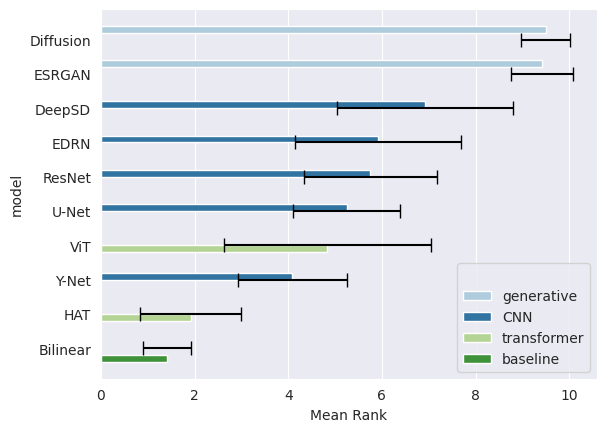

In [11]:
metric_common = 'msssim'
df_tmp = ranks_agg_eobs[1]
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize(df_list2_agg)
plt.savefig("final_image.png")

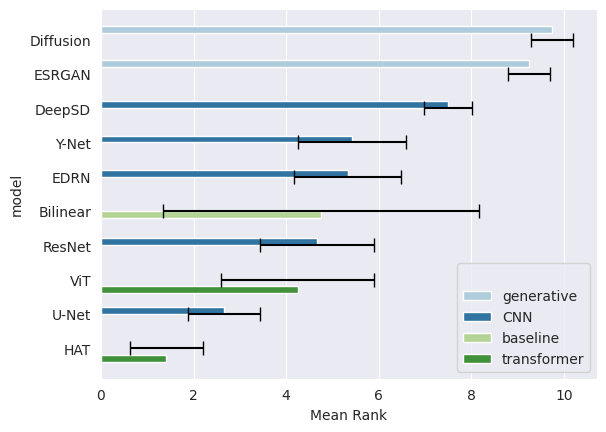

In [12]:
metric_common = 'lat_psnr'
df_tmp = ranks_agg_eobs[2]
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize(df_list2_agg)
plt.savefig("final_image.png", transparent=True)

In [154]:
ranks_agg_eobs, ranks_raw_eobs = get_ranks(['metrics_42_eobs.pkl', 'metrics_123_eobs.pkl', 'metrics_777_eobs.pkl'], metrics_to_select)

eobs
eobs
eobs


KeyError: "None of [Index(['test/lat_rmse:air_temperature_argsort',\n       'test/lat_rmse:precipitation_argsort',\n       'test/lat_rmse:u_component_of_wind_argsort',\n       'test/lat_rmse:v_component_of_wind_argsort',\n       'test/SSIM:air_temperature_argsort', 'test/SSIM:precipitation_argsort',\n       'test/SSIM:u_component_of_wind_argsort',\n       'test/SSIM:v_component_of_wind_argsort',\n       'test/lat_PSNR:air_temperature_argsort',\n       'test/lat_PSNR:precipitation_argsort',\n       'test/lat_PSNR:u_component_of_wind_argsort',\n       'test/lat_PSNR:v_component_of_wind_argsort',\n       'test/lat_mean_bias:air_temperature_argsort',\n       'test/lat_mean_bias:precipitation_argsort',\n       'test/lat_mean_bias:u_component_of_wind_argsort',\n       'test/lat_mean_bias:v_component_of_wind_argsort',\n       'test/pearson:air_temperature_argsort',\n       'test/pearson:precipitation_argsort',\n       'test/pearson:u_component_of_wind_argsort',\n       'test/pearson:v_compone

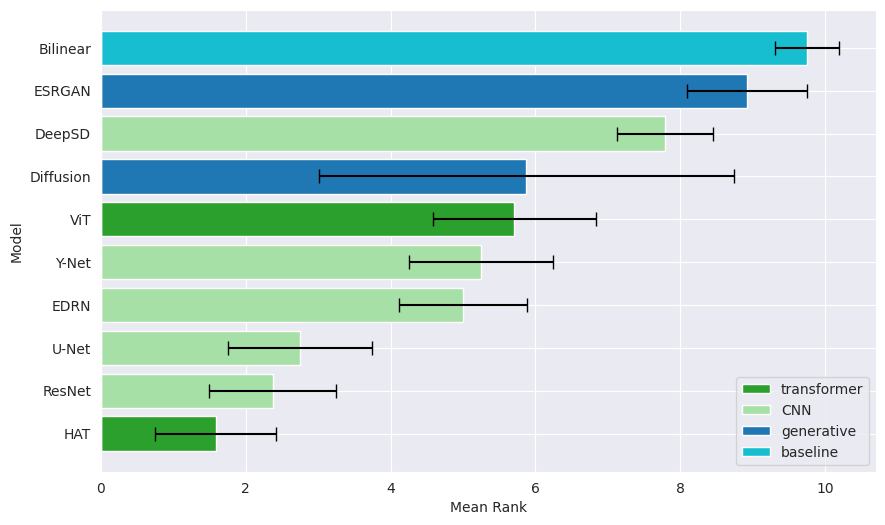

In [163]:
df_tmp = pd.concat([ranks_raw_cmip[0], ranks_raw_era[0]]).groupby('level_0').agg(['mean', 'std']).reset_index()
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize2(df_list2_agg, 'era_and_cmip')
plt.savefig("final_image.png")

In [158]:
df_tmp

rmse          
               mean       std
level_0                      
baseline   9.750000  0.442326
deepsd     7.791667  0.658005
diffusion  5.875000  2.863754
edrn       5.000000  0.884652
esrgan     8.916667  0.829702
hat        1.583333  0.829702
resnet     2.375000  0.875388
unet       2.750000  0.989071
vit        5.708333  1.122078
ynet       5.250000  0.989071

In [144]:
df_tmp.reset_index

rmse          
               mean       std
level_0                      
baseline   9.041667  2.349453
deepsd     8.250000  1.073394
diffusion  5.625000  2.825543
edrn       5.250000  1.151558
esrgan     8.541667  0.779028
hat        1.375000  0.710939
resnet     2.500000  0.834058
unet       3.000000  1.063219
vit        5.916667  1.316011
ynet       5.500000  0.932505

In [143]:
df_tmp = pd.concat([ranks_raw_cmip[1], ranks_raw_era[1]]).groupby('level_0').agg(['mean', 'std'])
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize2(df_list2_agg)
plt.savefig("final_image_MSSSIM.png")

TypeError: visualize2() missing 1 required positional argument: 'name'

AttributeError: Rectangle.set() got an unexpected keyword argument 'formatter'

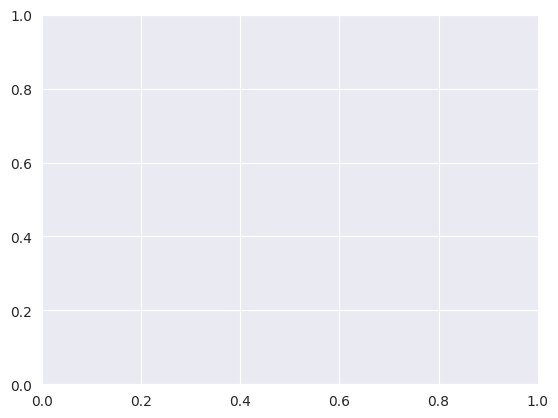

In [40]:
df_tmp = pd.concat([ranks_raw_cmip[2], ranks_raw_era[2]]).groupby('level_0').agg(['mean', 'std'])
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize(df_list2_agg)
plt.savefig("final_image_lat_PSNR.png")

In [152]:
ranks_raw_cmip[0]

,level_0,0
0,resnet,3.0
1,resnet,1.0
2,resnet,2.0
3,resnet,2.0
4,unet,4.0
...,...,...
115,diffusion,4.0
116,baseline,9.0
117,baseline,10.0
118,baseline,10.0


In [151]:
df_tmp = pd.concat([ranks_raw_cmip[0], ranks_raw_era[0]]).groupby('level_0').agg(['Mean Rank', 'std'])
df_tmp.rename(columns={0: metric_common}, inplace=True)
df_list2_agg = [df_tmp]
visualize(df_list2_agg, 'final_image')
plt.savefig("final_image.png")

AttributeError: 'SeriesGroupBy' object has no attribute 'Mean Rank'

In [149]:
df_tmp

,model_name,Mean Rank,Std Rank
0,baseline,8.000000,0.000000
1,deepsd,7.000000,0.000000
2,diffusion,9.750000,0.452267
3,edrn,4.833333,1.114641
4,esrgan,9.250000,0.452267
5,hat,1.250000,0.621582
6,resnet,4.083333,1.083625
7,unet,2.166667,0.834847
8,vit,3.666667,1.614330
9,ynet,5.000000,0.852803


AttributeError: Rectangle.set() got an unexpected keyword argument 'formatter'

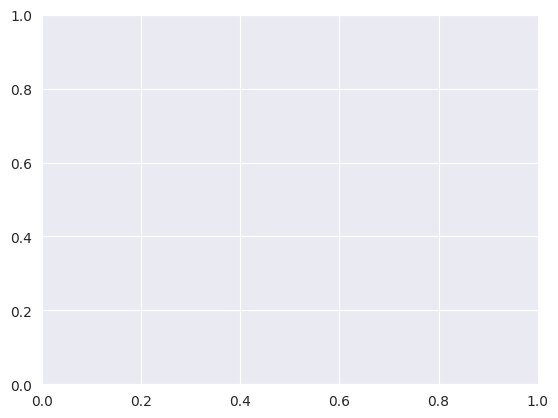

In [42]:
visualize(ranks_agg_era)
plt.title("just era5")

AttributeError: Rectangle.set() got an unexpected keyword argument 'formatter'

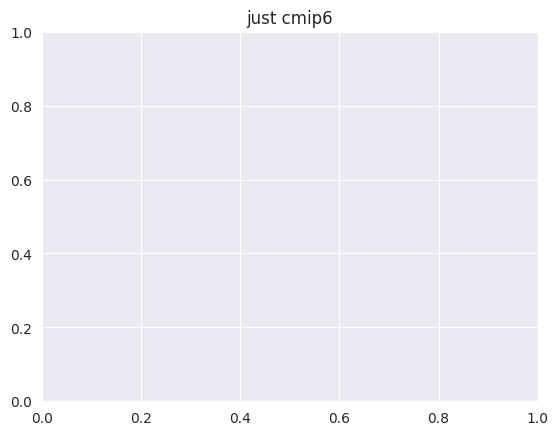

In [43]:
plt.title("just cmip6")
visualize(ranks_agg_cmip)

In [44]:
df_concat[cols].stack().reset_index().drop('level_1', axis=1).groupby('level_0').agg(['mean', 'std', 'count'])

NameError: name 'df_concat' is not defined

In [45]:
df_concat[cols].stack().reset_index().drop('level_1', axis=1).groupby('level_0').agg(['mean', 'std', 'count'])

NameError: name 'df_concat' is not defined